# PHASE 1: MATHEMATICAL MODELING OF BLOOD FLOW

## Vector
A vector represents both magnitude and direction. In this project, vectors are used to represent blood flow movement.

## Vector Field
A vector field assigns a vector to every point in a region, helping visualize blood flow patterns throughout an artery.

## Vector Field Used
F(x,y) = (-y, x)

This vector field creates a circular flow pattern around the center and is used to simulate rotational blood flow.

## Rotational Flow
Rotational flow occurs when fluid moves in a circular or swirling pattern instead of a straight path.

## Curl
Curl measures the amount of rotation in a vector field.

For F(x,y) = (-y, x):

Curl = 2

A positive curl indicates counter-clockwise rotational flow.

## Project Goal
Model blood flow using vector calculus, extract mathematical flow characteristics, and later combine them with healthcare data and machine learning for cardiovascular risk prediction.

## Vector Field Visualization

The vector field F(x,y)=(-y,x) is visualized to observe blood-flow direction and rotational behavior. The arrows form a counter-clockwise circular pattern, confirming the presence of rotational flow.

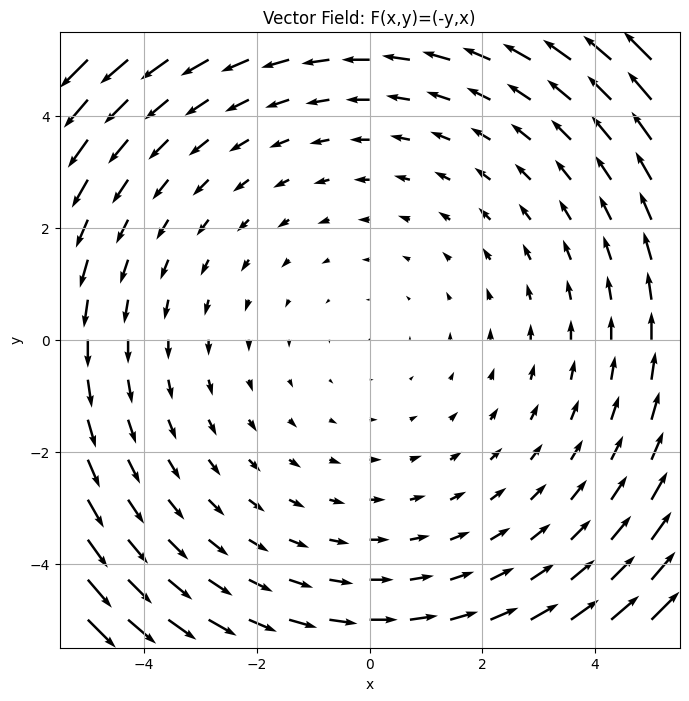

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 15)
y = np.linspace(-5, 5, 15)

X, Y = np.meshgrid(x, y)

U = -Y
V = X

plt.figure(figsize=(8,8))
plt.quiver(X, Y, U, V)

plt.title("Vector Field: F(x,y)=(-y,x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

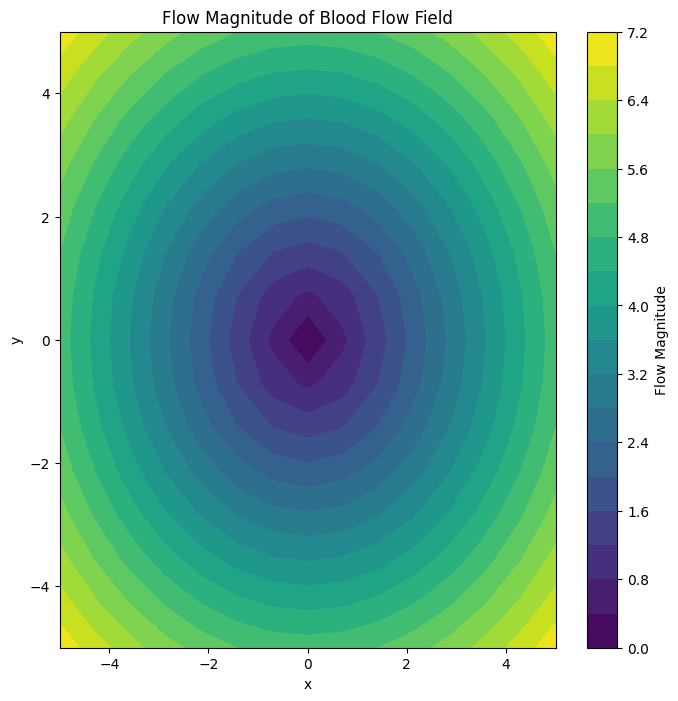

In [2]:
magnitude = np.sqrt(U**2 + V**2)
plt.figure(figsize=(8,8))
plt.contourf(X, Y, magnitude, levels=20)
plt.colorbar(label="Flow Magnitude")
plt.title("Flow Magnitude of Blood Flow Field")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [3]:
dU_dx = 0
dV_dy = 0
divergence = dU_dx + dV_dy
print("Divergence =", divergence)

Divergence = 0


In [4]:
# Green's Theorem Components
def M(x, y):
    return -y

def N(x, y):
    return x

dN_dx = 1
dM_dy = -1

curl = dN_dx - dM_dy
print("Curl =", curl)

Curl = 2


In [5]:
max_magnitude = np.max(magnitude)
mean_magnitude = np.mean(magnitude)
dU_dx = 0
dV_dy = 0
divergence = dU_dx + dV_dy
curl = 2
print("Maximum Flow Magnitude:", round(max_magnitude, 2))
print("Average Flow Magnitude:", round(mean_magnitude, 2))
print("Divergence:", divergence)
print("Curl:", curl)

Maximum Flow Magnitude: 7.07
Average Flow Magnitude: 4.09
Divergence: 0
Curl: 2


# Phase 2: Data Analytics

This phase focuses on analyzing healthcare data and identifying relationships between patient characteristics and cardiovascular health indicators. Exploratory Data Analysis (EDA), statistical analysis, and feature engineering are used to uncover patterns that can support predictive modeling.

In [6]:
import pandas as pd
data = pd.read_csv("heart_disease_data.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0
1,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
2,44,0,2,118,242,0,1,149,0,0.3,1,1,2,1
3,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
4,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1


In [7]:
data.shape

(606, 14)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       606 non-null    int64  
 1   sex       606 non-null    int64  
 2   cp        606 non-null    int64  
 3   trestbps  606 non-null    int64  
 4   chol      606 non-null    int64  
 5   fbs       606 non-null    int64  
 6   restecg   606 non-null    int64  
 7   thalach   606 non-null    int64  
 8   exang     606 non-null    int64  
 9   oldpeak   606 non-null    float64
 10  slope     606 non-null    int64  
 11  ca        606 non-null    int64  
 12  thal      606 non-null    int64  
 13  target    606 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 66.4 KB


In [9]:
data["target"].value_counts()

,count
target,
1,330
0,276


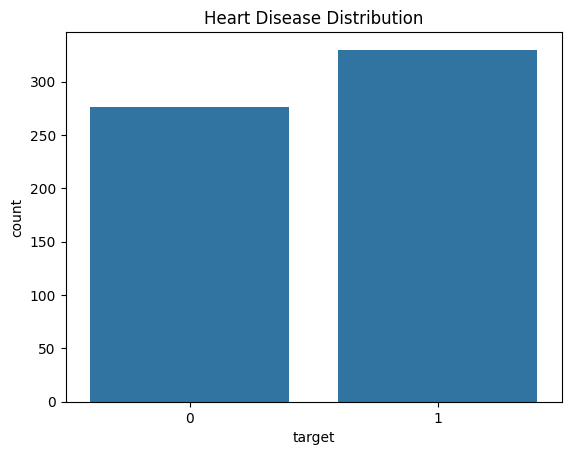

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=data)
plt.title("Heart Disease Distribution")
plt.show()

In [11]:
data[["age", "trestbps", "chol", "thalach"]].describe()

,age,trestbps,chol,thalach
count,606.000000,606.000000,606.000000,606.000000
mean,54.366337,131.623762,246.264026,149.646865
std,9.074592,17.523642,51.787898,22.886223
min,29.000000,94.000000,126.000000,71.000000
25%,47.250000,120.000000,211.000000,133.250000
50%,55.000000,130.000000,240.000000,153.000000
75%,61.000000,140.000000,274.750000,166.000000
max,77.000000,200.000000,564.000000,202.000000


In [12]:
data.groupby("target")[["age","trestbps","chol","thalach"]].mean()

,age,trestbps,chol,thalach
target,,,,
0,56.601449,134.398551,251.086957,139.101449
1,52.496970,129.303030,242.230303,158.466667


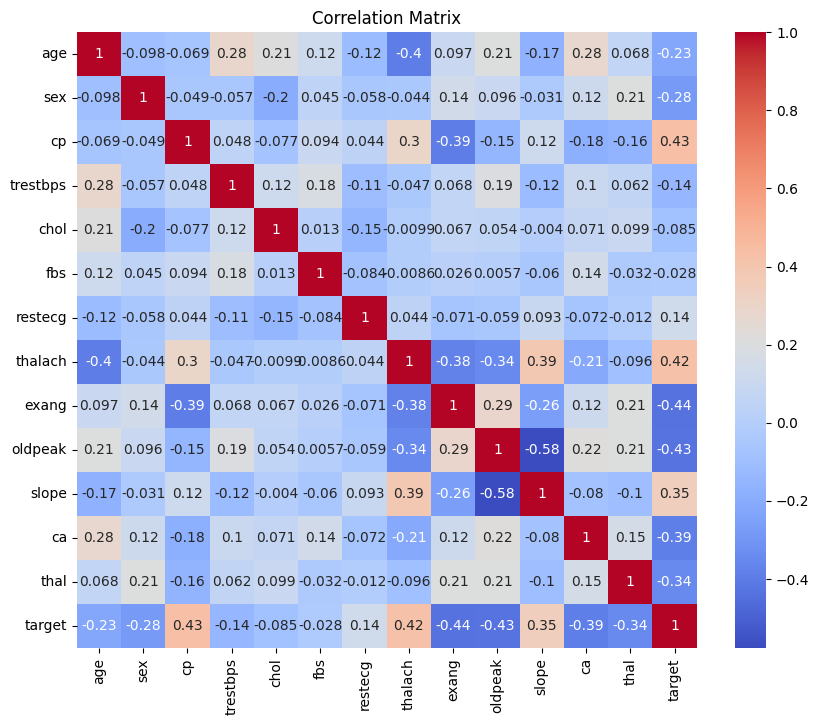

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [14]:
data["BP_Chol_Ratio"] = data["trestbps"] / data["chol"]
data[["trestbps", "chol", "BP_Chol_Ratio"]].head()

,trestbps,chol,BP_Chol_Ratio
0,130,256,0.507812
1,148,203,0.729064
2,118,242,0.487603
3,110,275,0.400000
4,120,193,0.621762


In [15]:
data["BP_Chol_Ratio"].describe()

,BP_Chol_Ratio
count,606.000000
mean,0.555179
std,0.127796
min,0.203901
25%,0.462034
50%,0.538813
75%,0.635165
max,1.190476


In [16]:
data["Age_BP_Index"] = data["age"] * data["trestbps"]
data[["age", "trestbps", "Age_BP_Index"]].head()

,age,trestbps,Age_BP_Index
0,48,130,6240
1,61,148,9028
2,44,118,5192
3,47,110,5170
4,56,120,6720


In [17]:
data["Age_BP_Index"].describe()

,Age_BP_Index
count,606.000000
mean,7200.250825
std,1739.380309
min,3666.000000
25%,5862.000000
50%,7140.000000
75%,8361.250000
max,12240.000000


In [18]:
corr_target = data.corr()["target"].sort_values(ascending=False)
print(corr_target)

target           1.000000
cp               0.433798
thalach          0.421741
slope            0.345877
restecg          0.137230
BP_Chol_Ratio    0.000723
fbs             -0.028046
chol            -0.085239
trestbps        -0.144931
age             -0.225439
Age_BP_Index    -0.232836
sex             -0.280937
thal            -0.344029
ca              -0.391724
oldpeak         -0.430696
exang           -0.436757
Name: target, dtype: float64


In [19]:
import numpy as np
data["Flow_Magnitude"] = np.sqrt(
    data["trestbps"]**2 +
    data["thalach"]**2
)

data[["trestbps", "thalach", "Flow_Magnitude"]].head()

,trestbps,thalach,Flow_Magnitude
0,130,150,198.494332
1,148,161,218.689277
2,118,149,190.065778
3,110,118,161.319559
4,120,162,201.603571


In [20]:
corr_target = data.corr()["target"].sort_values(ascending=False)
print(corr_target["Flow_Magnitude"])

0.26614298135447284


In [21]:
features = [
    "cp",
    "thalach",
    "slope",
    "age",
    "trestbps",
    "chol",
    "oldpeak",
    "exang",
    "ca",
    "thal",
    "BP_Chol_Ratio",
    "Age_BP_Index",
    "Flow_Magnitude"
]

X = data[features]
y = data["target"]

print(X.shape)
print(y.shape)

(606, 13)
(606,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(484, 13)
(122, 13)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Phase 3: Machine Learning

This phase focuses on building predictive models using healthcare and engineered features. Machine learning algorithms are trained and evaluated to predict heart disease risk, identify important risk factors, and assess model performance using classification metrics.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8033


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.70      0.74        50
           1       0.81      0.88      0.84        72

    accuracy                           0.80       122
   macro avg       0.80      0.79      0.79       122
weighted avg       0.80      0.80      0.80       122



In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.9344


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92        50
           1       0.92      0.97      0.95        72

    accuracy                           0.93       122
   macro avg       0.94      0.93      0.93       122
weighted avg       0.94      0.93      0.93       122



In [28]:
import pandas as pd
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
print(importance_df)

           Feature  Importance
0               cp    0.150729
1          thalach    0.104292
8               ca    0.103443
6          oldpeak    0.097792
9             thal    0.089424
12  Flow_Magnitude    0.071030
11    Age_BP_Index    0.065478
3              age    0.061862
7            exang    0.058265
5             chol    0.055664
10   BP_Chol_Ratio    0.049805
4         trestbps    0.048100
2            slope    0.044116


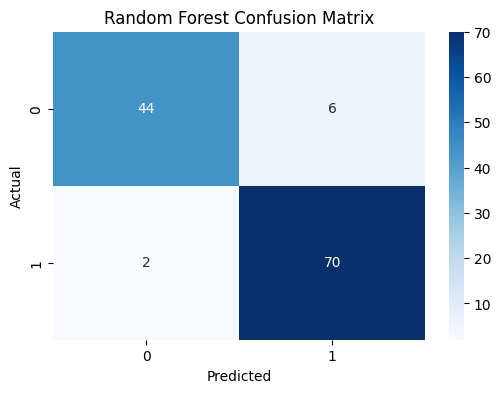

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

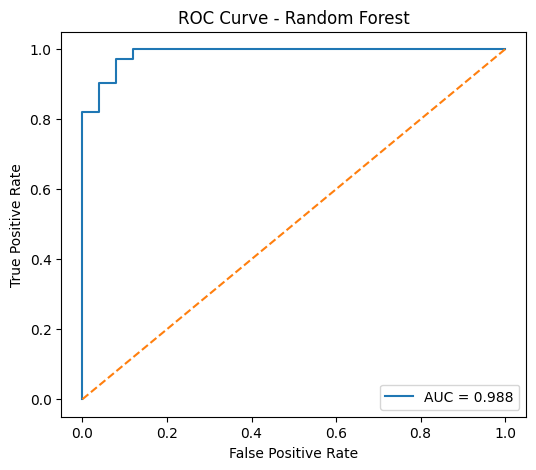

AUC Score: 0.9877777777777778


In [30]:
from sklearn.metrics import roc_curve, auc
y_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

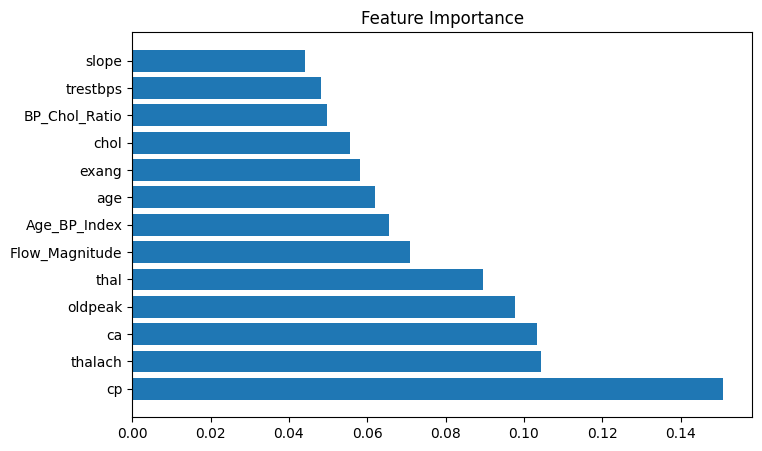

In [31]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")
plt.show()

In [32]:
import joblib
joblib.dump(rf_model, "heart_disease_rf_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [33]:
import joblib
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully!")

Scaler saved successfully!


In [34]:
sample_patient = [[
    3,      # cp
    150,    # thalach
    2,      # slope
    55,     # age
    130,    # trestbps
    250,    # chol
    1.2,    # oldpeak
    0,      # exang
    0,      # ca
    2,      # thal
    130/250,                # BP_Chol_Ratio
    55*130,                 # Age_BP_Index
    (130**2 + 150**2)**0.5  # Flow_Magnitude
]]

prediction = rf_model.predict(sample_patient)

if prediction[0] == 1:
    print("High Risk of Heart Disease")
else:
    print("Low Risk of Heart Disease")

Low Risk of Heart Disease


In [35]:
cp = int(input("Chest Pain Type (0-3): "))
thalach = float(input("Maximum Heart Rate: "))
slope = int(input("Slope (0-2): "))
age = int(input("Age: "))
trestbps = float(input("Resting Blood Pressure: "))
chol = float(input("Cholesterol: "))
oldpeak = float(input("Oldpeak: "))
exang = int(input("Exercise Induced Angina (0/1): "))
ca = int(input("Number of Major Vessels (0-4): "))
thal = int(input("Thal (0-3): "))

# Mathematical Features
BP_Chol_Ratio = trestbps / chol
Age_BP_Index = age * trestbps
Flow_Magnitude = (trestbps**2 + thalach**2) ** 0.5

patient_data = [[
    cp,
    thalach,
    slope,
    age,
    trestbps,
    chol,
    oldpeak,
    exang,
    ca,
    thal,
    BP_Chol_Ratio,
    Age_BP_Index,
    Flow_Magnitude
]]

prediction = rf_model.predict(patient_data)

if prediction[0] == 1:
    print("\n⚠️ High Risk of Heart Disease")
else:
    print("\n✅ Low Risk of Heart Disease")

Chest Pain Type (0-3): 2
Maximum Heart Rate: 120
Slope (0-2): 2
Age: 50
Resting Blood Pressure: 140
Cholesterol: 220
Oldpeak: 1
Exercise Induced Angina (0/1): 1
Number of Major Vessels (0-4): 0
Thal (0-3): 1

✅ Low Risk of Heart Disease


#Phase 4: Deployment

The final phase focuses on deploying the trained Random Forest model for real-world heart disease prediction. User-provided medical parameters are processed to generate mathematical features such as Flow_Magnitude, BP_Chol_Ratio, and Age_BP_Index. These features are then passed to the trained model to predict heart disease risk. This phase demonstrates the practical integration of mathematics, data analytics, and machine learning in healthcare decision support systems.

# Project Conclusion

This project integrated mathematical modeling, healthcare analytics, and machine learning to assess cardiovascular risk. Vector calculus concepts were used to model blood flow behavior, while exploratory data analysis and feature engineering were applied to patient health data. Multiple machine learning models were evaluated, with Random Forest achieving the best performance of 93.4% accuracy. The project demonstrates the application of mathematics, data analytics, and predictive modeling in healthcare.